# Preexperimento (1/3): *Screening* de Diferenciación Fraccionaria (FFD)

Documenta el cribado FFD por símbolo y variable (OHLCV + técnicos y bloque contextual). **No** cierra el *subset* productivo: la *whitelist* vive en `reports/validation/features/fracdiff_whitelist_frozen.json` y la calibración efectiva por *fold* ocurre en el *loop* de entrenamiento.

**Relación con el resto del preexperimento:** este notebook y `04_preexperimento/02_resultados_screening_columnas_por_fuente.ipynb` son evidencias paralelas; `04_preexperimento/03_presentacion_screening_variables_y_ffd_por_fuente.ipynb` actúa como síntesis visual para presentación.

## Qué responde este notebook

1. Qué variables **ya son estacionarias** y no necesitan FFD.
2. Qué variables **mejoran con FFD** en `train` y validan fuera de muestra en `test`.
3. Qué variables **parecen funcionar en `train` pero fallan en `test`** y, por tanto, deben descartarse por ahora.
4. Qué subconjunto de columnas queda documentado como **candidatas a FFD** a nivel metodológico por símbolo y variable.
5. Qué columnas contextuales se descartan antes del *screening* por *sparse*, baja persistencia, exceso de nulos, estado de fuente o transformación/acotación previa.

## Alcance

- Símbolos: se leen desde `config/settings.yaml`.
- Variables evaluadas:
  - OHLCV base: `open`, `high`, `low`, `close`, `volume`, `taker_buy_asset_volume`, `num_trades`
  - Indicadores técnicos del `FeatureRegistry` actual
  - Revisión contextual: derivados, *on-chain* y microestructura desde la matriz intermedia causal.
- Metodología: calibración `d*` en `train` y validación fuera de muestra en `test` sin recalibrar.


In [14]:
import logging
import os
import sys
import warnings
from pathlib import Path

import structlog

warnings.filterwarnings("ignore")

structlog.reset_defaults()
structlog.configure(
    processors=[structlog.processors.JSONRenderer()],
    logger_factory=structlog.PrintLoggerFactory(
        file=open(os.devnull, "w", encoding="utf-8")
    ),
    wrapper_class=structlog.make_filtering_bound_logger(logging.CRITICAL),
    cache_logger_on_first_use=True,
)
_root = logging.getLogger()
_root.setLevel(logging.CRITICAL)
for _handler in list(_root.handlers):
    _handler.setLevel(logging.CRITICAL)
for _logger_name in ("sqlalchemy.engine", "sqlalchemy.pool"):
    logging.getLogger(_logger_name).setLevel(logging.CRITICAL)

ROOT = Path.cwd().resolve()
while not (ROOT / "config").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    def load_dotenv(*_args, **_kwargs) -> bool:
        return False

from src.config.settings import Settings
from src.utils.database import create_db_engine
from src.features.assembler import load_ohlcv
from src.features.registry import FeatureRegistry
from src.features.technical import compute_feature
from src.features.fracdiff import (
    FFD_SCREENING_KWARGS,
    screen_fracdiff_candidates,
)


def rename_cols_es(df: pd.DataFrame, mapping: dict[str, str]) -> pd.DataFrame:
    """Renombra columnas solo para lectura en el notebook. Los CSV y el pipeline conservan nombres originales"""
    to_apply = {c: mapping[c] for c in df.columns if c in mapping}
    return df.rename(columns=to_apply)


# Etiquetas en español 
COLUMNS_MANIFEST_ES: dict[str, str] = {
    "symbol": "simbolo",
    "rows_total": "filas_total",
    "rows_train": "filas_train",
    "rows_test": "filas_test",
    "start": "inicio_utc",
    "end": "fin_utc",
    "n_variables": "n_columnas",
}

# Detalle de screening: nombres de métricas (ADF, correlación) razonables en español
COLUMNS_SCREENING_ES: dict[str, str] = {
    "symbol": "simbolo",
    "series_name": "serie",
    "baseline_adf_stat": "adf_baseline",
    "baseline_pvalue": "p_valor_baseline",
    "baseline_stationary": "estacionaria_baseline",
    "d_star": "d_optimo",
    "train_adf_stat": "adf_train",
    "train_pvalue": "p_valor_train",
    "train_stationary": "estacionaria_train",
    "train_corr": "correlacion_train",
    "test_adf_stat": "adf_test",
    "test_pvalue": "p_valor_test",
    "test_stationary": "estacionaria_test",
    "test_corr": "correlacion_test",
    "recommended_action": "accion",
    "decision_reason": "motivo",
}

COLUMNS_RESUMEN_VARIABLE_ES: dict[str, str] = {
    "series_name": "serie",
    "n_symbols": "n_simbolos",
    "apply_count": "n_simbolos_con_apply",
    "skip_count": "n_simbolos_skip",
    "baseline_stationary_count": "n_baseline_ya_estacionaria",
    "median_d_star": "mediana_d_optimo",
    "mean_train_corr": "media_correlacion_train",
    "mean_test_corr": "media_correlacion_test",
    "mean_test_pvalue": "media_p_valor_test",
    "apply_ratio": "proporcion_apply",
}

COLUMNS_DECISION_FFD_ES: dict[str, str] = {
    "series_name": "serie",
    "n_symbols": "n_simbolos",
    "apply_count": "n_simbolos_con_apply",
    "apply_ratio": "proporcion_apply",
    "symbols_with_apply": "simbolos_con_apply",
    "median_d_star": "mediana_d_optimo",
    "mean_train_corr": "media_correlacion_train",
    "mean_test_corr": "media_correlacion_test",
    "mean_test_pvalue": "media_p_valor_test",
    "final_decision": "decision_final",
    "discard_reason_or_acceptance": "criterio",
}

COLUMNS_RESUMEN_DECISION_ES: dict[str, str] = {
    "final_decision": "decision_final",
    "discard_reason_or_acceptance": "criterio",
    "count": "frecuencia",
}

COLUMNS_POR_SIMBOLO_ES: dict[str, str] = {
    "symbol": "simbolo",
    "n_apply": "n_candidatas_ffd",
    "n_skip": "n_no_ffd",
    "n_pairs": "n_columnas_evaluadas",
}

COLUMNS_PROFILE_CONTEXTUAL_ES: dict[str, str] = {
    "source": "fuente",
    "column": "columna",
    "symbols_with_data": "n_simbolos_con_datos",
    "max_missing_ratio": "max_proporcion_nulos",
    "median_zero_ratio": "mediana_proporcion_ceros",
    "min_unique_values": "min_valores_unicos",
    "median_lag1_autocorr": "mediana_autocorrelacion_lag1",
    "median_abs_trend_corr": "mediana_correlacion_tendencia_abs",
    "candidate": "es_candidata",
    "decision_reason": "motivo",
}

COLUMNS_RESUMEN_CONTEXTUAL_ES: dict[str, str] = {
    "series_name": "serie",
    "n_symbols": "n_simbolos",
    "apply_count": "n_simbolos_con_apply",
    "apply_ratio": "proporcion_apply",
    "median_d_star": "mediana_d_optimo",
    "min_train_corr": "min_correlacion_train",
    "min_test_corr": "min_correlacion_test",
}

# Split cronológico train/test 
TRAIN_TEST_SPLIT_FRAC = 0.8

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

REPORT_DIR = ROOT / "reports" / "eda" / "fracdiff" / "screening"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(ROOT / ".env")
settings = Settings.load_from_yaml(ROOT / "config" / "settings.yaml")


## Protocolo de decisión

Cada variable se evalúa de forma independiente con este criterio:

1. **ADF baseline en `train`**
   - Si la serie ya es estacionaria, se marca `skip`.
2. **Calibración de `d*` solo en `train`**
   - Grid: `d ∈ [0.0, 1.0]` con paso `0.05` (en código: `FFD_D_RANGE`, `FFD_D_STEP` en `src/features/fracdiff.py`).
3. **Aplicación de `d*` a `train` y `test` sin recalibrar**
   - Esto fuerza un protocolo *anti-leakage* real.
4. **Criterio para marcar `apply` (por símbolo y columna)**
   - No estacionaria en baseline.
   - Estacionaria tras FFD en `train`.
   - Estacionaria tras FFD en `test`.
   - Conserva memoria suficiente (umbrales alineados con el código):
     - `train_corr >= FFD_MIN_TRAIN_CORR` (0.80)
     - `test_corr >= FFD_MIN_TEST_CORR` (0.70)
   - En las celdas de *screening* se llama a `screen_fracdiff_candidates(..., **FFD_SCREENING_KWARGS)`; ese dict fija además `threshold` (τ = `FFD_WEIGHT_THRESHOLD`) y `alpha` = `FFD_ADF_ALPHA` (ADF), de modo que el markdown y el código comparten la misma fuente de verdad.

**Split `train`/`test` (este notebook):** se usa el `TRAIN_TEST_SPLIT_FRAC` de la primera celda de código (0.8); no entra en `FFD_SCREENING_KWARGS` porque el contraste `train`/`test` es responsabilidad del notebook.

**Agregación multisímbolo:** `apply_count` y `apply_ratio` son métricas descriptivas de cobertura. La decisión no usa un umbral global entre símbolos: una variable queda preparada para FFD en los símbolos donde exista al menos una fila `apply` validada por el *screening*.

## Lectura correcta de resultados

- `apply`: candidata razonable a FFD para ese símbolo y columna.
- `skip/baseline_stationary`: no necesita FFD.
- `skip/oos_not_stationary_after_ffd`: parecía útil en `train`, pero **no generaliza**.
- `skip/low_*_memory_retention`: estacionariza, pero destruye demasiada memoria.

In [15]:
engine = create_db_engine()
SYMBOLS = settings.trading_universe.symbols

if not engine:
    raise RuntimeError("No se pudo crear la conexión a la base de datos.")


In [16]:
def compute_technical_matrix(ohlcv_df: pd.DataFrame) -> pd.DataFrame:
    """Replica el cálculo técnico del pipeline para screening metodológico"""
    registry = FeatureRegistry()
    tech = pd.DataFrame(index=ohlcv_df.index)

    specs = registry.all_specs()
    independent = [s for s in specs if s.func_name != "slope"]
    dependent = [s for s in specs if s.func_name == "slope"]

    for spec in independent:
        tech[spec.name] = compute_feature(spec, ohlcv_df, tech)
    for spec in dependent:
        tech[spec.name] = compute_feature(spec, ohlcv_df, tech)

    return tech


def build_candidate_matrix(symbol: str) -> pd.DataFrame:
    """Construye OHLCV + técnicos para un símbolo"""
    ohlcv_df = load_ohlcv(engine, symbol)
    if ohlcv_df.empty:
        raise ValueError(f"No se encontró OHLCV para {symbol}.")

    tech_df = compute_technical_matrix(ohlcv_df)
    candidates = pd.concat([ohlcv_df, tech_df], axis=1)
    candidates.index.name = "timestamp"
    return candidates


def split_train_test(
    df: pd.DataFrame, train_ratio: float = TRAIN_TEST_SPLIT_FRAC
) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_idx = int(len(df) * train_ratio)
    return df.iloc[:split_idx], df.iloc[split_idx:]


def save_df(df: pd.DataFrame, filename: str) -> Path:
    path = REPORT_DIR / filename
    df.to_csv(path, index=False)
    return path

In [17]:
candidate_matrices: dict[str, pd.DataFrame] = {}
manifest_rows: list[dict[str, object]] = []

for symbol in SYMBOLS:
    matrix = build_candidate_matrix(symbol)
    candidate_matrices[symbol] = matrix
    train_df, test_df = split_train_test(matrix)

    manifest_rows.append(
        {
            "symbol": symbol,
            "rows_total": len(matrix),
            "rows_train": len(train_df),
            "rows_test": len(test_df),
            "start": matrix.index.min(),
            "end": matrix.index.max(),
            "n_variables": len(matrix.columns),
        }
    )

manifest_df = pd.DataFrame(manifest_rows)
save_df(manifest_df, "manifest_symbols.csv")

display(rename_cols_es(manifest_df, COLUMNS_MANIFEST_ES))

,simbolo,filas_total,filas_train,filas_test,inicio_utc,fin_utc,n_columnas
0,BTCUSDT,19277,15421,3856,2017-08-17 04:00:00,2026-06-03 20:00:00,29
1,ETHUSDT,19254,15403,3851,2017-08-17 04:00:00,2026-05-31 00:00:00,29
2,BNBUSDT,18769,15015,3754,2017-11-06 00:00:00,2026-05-31 00:00:00,29
3,XRPUSDT,17693,14154,3539,2018-05-04 08:00:00,2026-05-31 00:00:00,29
4,SOLUSDT,12714,10171,2543,2020-08-11 04:00:00,2026-05-31 00:00:00,29


## Ejecución del *screening* FFD

Esta sección genera:

- un CSV por símbolo con el detalle completo del *screening*,
- un CSV consolidado con todos los símbolos,
- una tabla agregada por variable,
- gráficos de soporte para la revisión metodológica.

> El tiempo de ejecución puede ser de varios minutos porque se calibra `d*` por columna y por símbolo.

In [18]:
combined_rows: list[pd.DataFrame] = []

for symbol, matrix in candidate_matrices.items():
    train_df, test_df = split_train_test(matrix)
    screening_df = screen_fracdiff_candidates(
        train_df,
        test_df,
        columns=list(matrix.columns),
        **FFD_SCREENING_KWARGS,
    )
    screening_df.insert(0, "symbol", symbol)
    save_df(screening_df, f"screening_{symbol.lower()}.csv")
    combined_rows.append(screening_df)

screening_all_df = pd.concat(combined_rows, ignore_index=True)
save_df(screening_all_df, "screening_all_symbols.csv")

display(
    rename_cols_es(screening_all_df.head(20), COLUMNS_SCREENING_ES)
)

,simbolo,serie,p_valor_baseline,estacionaria_baseline,d_optimo,p_valor_train,estacionaria_train,correlacion_train,p_valor_test,estacionaria_test,correlacion_test,accion,motivo,adf_baseline,adf_train,adf_test
0,BTCUSDT,bbands_lower_20,0.7673,False,0.3000,0.0294,True,0.9572,0.0418,True,0.8522,apply,accepted,-0.9607,-3.0629,-2.9320
1,BTCUSDT,bbands_upper_20,0.7486,False,0.3000,0.0467,True,0.9606,0.0175,True,0.8540,apply,accepted,-1.0127,-2.8885,-3.2464
2,BTCUSDT,close,0.7304,False,0.3000,0.0176,True,0.9526,0.0202,True,0.8355,apply,accepted,-1.0610,-3.2442,-3.1969
3,BTCUSDT,ema_12,0.7691,False,0.3500,0.0175,True,0.9501,0.0169,True,0.8209,apply,accepted,-0.9557,-3.2445,-3.2579
4,BTCUSDT,high,0.7171,False,0.3000,0.0205,True,0.9543,0.0136,True,0.8373,apply,accepted,-1.0948,-3.1911,-3.3288
5,BTCUSDT,low,0.7213,False,0.3000,0.0162,True,0.9505,0.0458,True,0.8324,apply,accepted,-1.0842,-3.2719,-2.8963
6,BTCUSDT,obv,0.8403,False,0.4000,0.0299,True,0.9356,0.0049,True,0.7655,apply,accepted,-0.7245,-3.0566,-3.6490
7,BTCUSDT,open,0.7265,False,0.3000,0.0172,True,0.9526,0.0166,True,0.8353,apply,accepted,-1.0710,-3.2504,-3.2624
8,BTCUSDT,sma_20,0.6942,False,0.3500,0.0318,True,0.9523,0.0268,True,0.8260,apply,accepted,-1.1513,-3.0349,-3.0967
9,BTCUSDT,sma_50,0.8533,False,0.4000,0.0450,True,0.9498,0.0154,True,0.8063,apply,accepted,-0.6741,-2.9029,-3.2882


In [19]:
feature_summary_df = (
    screening_all_df.groupby("series_name")
    .agg(
        n_symbols=("symbol", "count"),
        apply_count=("recommended_action", lambda s: int((s == "apply").sum())),
        skip_count=("recommended_action", lambda s: int((s == "skip").sum())),
        baseline_stationary_count=("baseline_stationary", lambda s: int(s.sum())),
        median_d_star=("d_star", "median"),
        mean_train_corr=("train_corr", "mean"),
        mean_test_corr=("test_corr", "mean"),
        mean_test_pvalue=("test_pvalue", "mean"),
    )
    .reset_index()
)
feature_summary_df["apply_ratio"] = (
    feature_summary_df["apply_count"] / feature_summary_df["n_symbols"]
)
feature_summary_df = feature_summary_df.sort_values(
    ["apply_count", "apply_ratio", "series_name"],
    ascending=[False, False, True],
)
save_df(feature_summary_df, "screening_feature_summary.csv")

any_symbol_apply_df = feature_summary_df[feature_summary_df["apply_count"] >= 1]
stable_apply_df = feature_summary_df[
    feature_summary_df["apply_count"] == feature_summary_df["n_symbols"]
]

display(rename_cols_es(any_symbol_apply_df, COLUMNS_RESUMEN_VARIABLE_ES))
display(rename_cols_es(stable_apply_df, COLUMNS_RESUMEN_VARIABLE_ES))
display(rename_cols_es(feature_summary_df, COLUMNS_RESUMEN_VARIABLE_ES))

,serie,n_simbolos,n_simbolos_con_apply,n_simbolos_skip,n_baseline_ya_estacionaria,mediana_d_optimo,media_correlacion_train,media_correlacion_test,media_p_valor_test,proporcion_apply
3,bbands_upper_20,5,2,3,1,0.2500,0.9697,0.9168,0.1610,0.4000
5,ema_12,5,2,3,1,0.2500,0.9655,0.9079,0.1172,0.4000
7,high,5,2,3,1,0.2000,0.9724,0.9242,0.1887,0.4000
8,low,5,2,3,1,0.2500,0.9662,0.9143,0.1322,0.4000
14,obv,5,2,3,1,0.4000,0.9299,0.6611,0.0031,0.4000
21,sma_20,5,2,3,1,0.3000,0.9625,0.9050,0.0822,0.4000
22,sma_50,5,2,3,0,0.3500,0.9566,0.8857,0.1415,0.4000
1,bbands_lower_20,5,1,4,1,0.2000,0.9739,0.9293,0.1211,0.2000
4,close,5,1,4,1,0.2000,0.9717,0.9232,0.1799,0.2000
6,ema_26,5,1,4,1,0.2500,0.9691,0.9148,0.1481,0.2000


,serie,n_simbolos,n_simbolos_con_apply,n_simbolos_skip,n_baseline_ya_estacionaria,mediana_d_optimo,media_correlacion_train,media_correlacion_test,media_p_valor_test,proporcion_apply


,serie,n_simbolos,n_simbolos_con_apply,n_simbolos_skip,n_baseline_ya_estacionaria,mediana_d_optimo,media_correlacion_train,media_correlacion_test,media_p_valor_test,proporcion_apply
3,bbands_upper_20,5,2,3,1,0.2500,0.9697,0.9168,0.1610,0.4000
5,ema_12,5,2,3,1,0.2500,0.9655,0.9079,0.1172,0.4000
7,high,5,2,3,1,0.2000,0.9724,0.9242,0.1887,0.4000
8,low,5,2,3,1,0.2500,0.9662,0.9143,0.1322,0.4000
14,obv,5,2,3,1,0.4000,0.9299,0.6611,0.0031,0.4000
21,sma_20,5,2,3,1,0.3000,0.9625,0.9050,0.0822,0.4000
22,sma_50,5,2,3,0,0.3500,0.9566,0.8857,0.1415,0.4000
1,bbands_lower_20,5,1,4,1,0.2000,0.9739,0.9293,0.1211,0.2000
4,close,5,1,4,1,0.2000,0.9717,0.9232,0.1799,0.2000
6,ema_26,5,1,4,1,0.2500,0.9691,0.9148,0.1481,0.2000


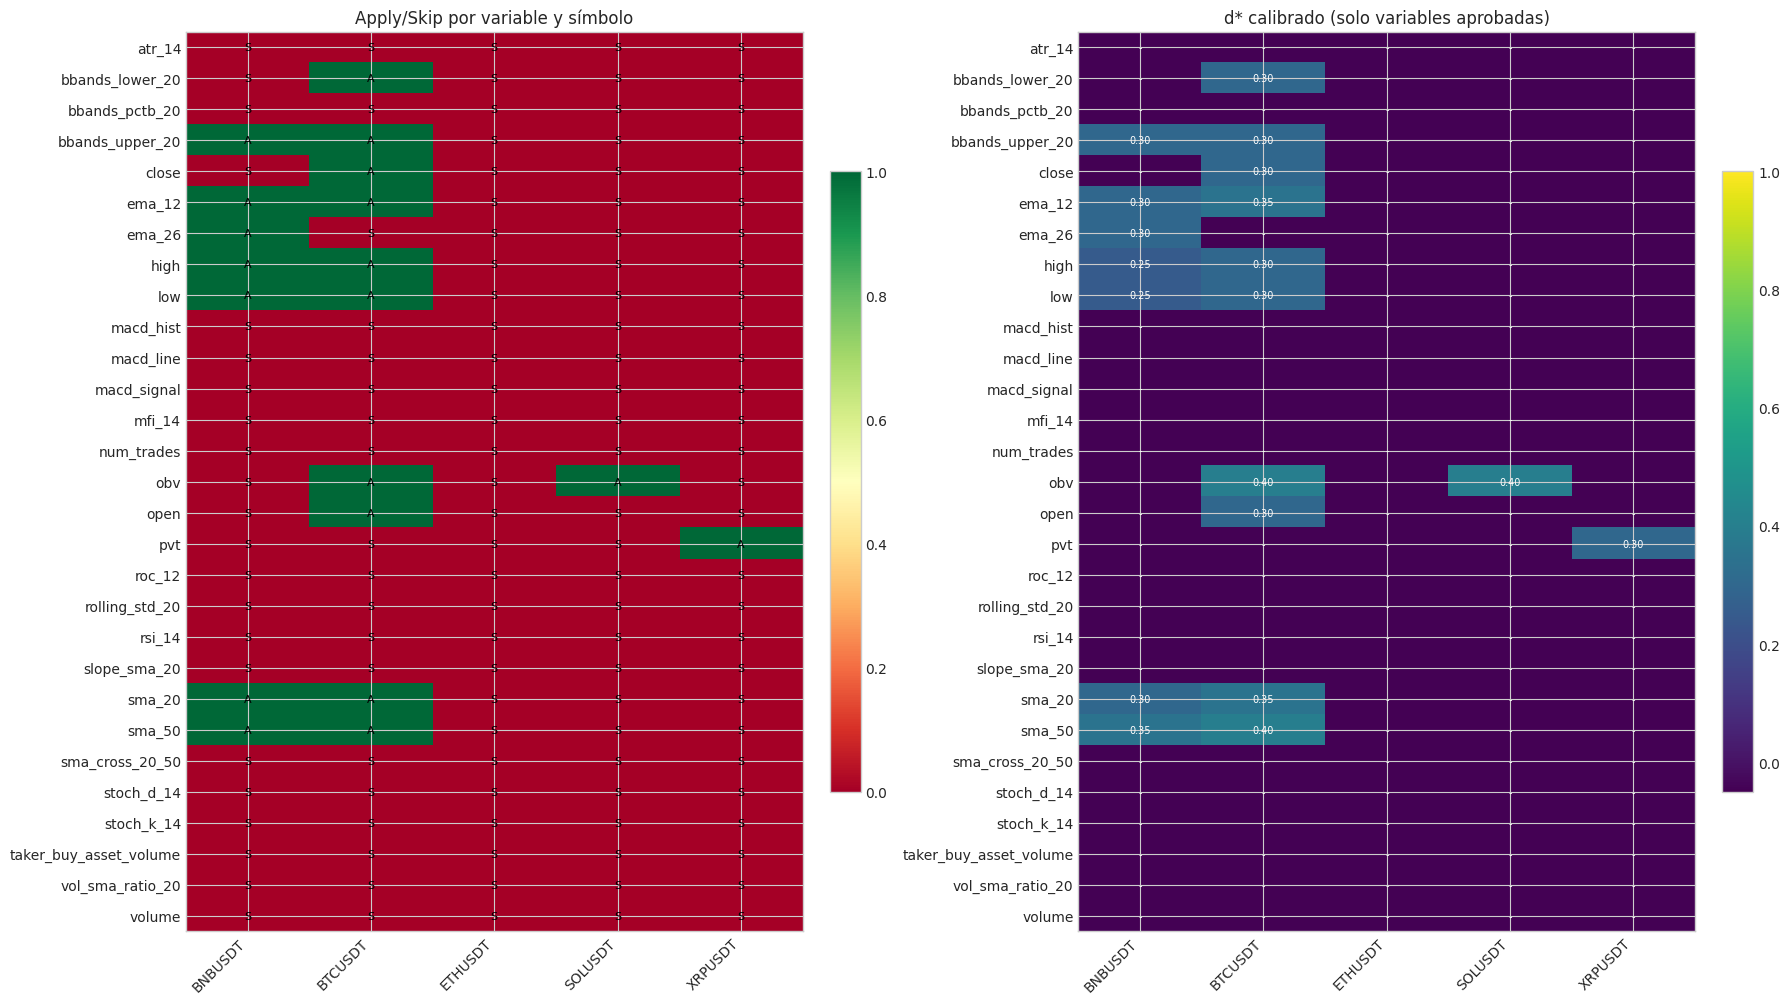

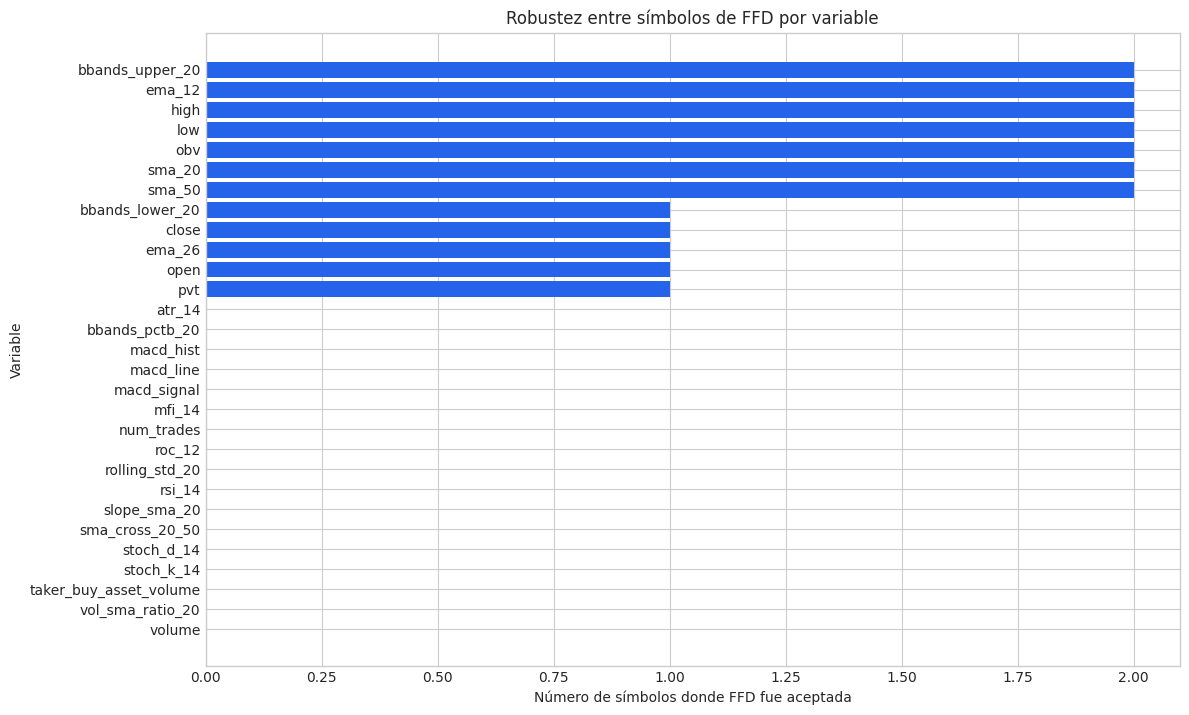

In [20]:
decision_matrix = screening_all_df.pivot(
    index="series_name", columns="symbol", values="recommended_action"
)
apply_matrix = (decision_matrix == "apply").astype(float)

dstar_matrix = screening_all_df.copy()
dstar_matrix.loc[dstar_matrix["recommended_action"] != "apply", "d_star"] = np.nan
dstar_matrix = dstar_matrix.pivot(
    index="series_name", columns="symbol", values="d_star"
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(decision_matrix) * 0.35)))

im0 = axes[0].imshow(apply_matrix.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_title("Apply/Skip por variable y símbolo")
axes[0].set_xticks(range(len(apply_matrix.columns)))
axes[0].set_xticklabels(apply_matrix.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(apply_matrix.index)))
axes[0].set_yticklabels(apply_matrix.index)
for i in range(apply_matrix.shape[0]):
    for j in range(apply_matrix.shape[1]):
        label = "A" if apply_matrix.iloc[i, j] == 1 else "S"
        axes[0].text(j, i, label, ha="center", va="center", color="black", fontsize=8)

im1 = axes[1].imshow(
    dstar_matrix.fillna(-0.05).values,
    aspect="auto",
    cmap="viridis",
    vmin=-0.05,
    vmax=1.0,
)
axes[1].set_title("d* calibrado (solo variables aprobadas)")
axes[1].set_xticks(range(len(dstar_matrix.columns)))
axes[1].set_xticklabels(dstar_matrix.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(dstar_matrix.index)))
axes[1].set_yticklabels(dstar_matrix.index)
for i in range(dstar_matrix.shape[0]):
    for j in range(dstar_matrix.shape[1]):
        val = dstar_matrix.iloc[i, j]
        label = "-" if pd.isna(val) else f"{val:.2f}"
        axes[1].text(j, i, label, ha="center", va="center", color="white", fontsize=7)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
heatmap_path = REPORT_DIR / "screening_heatmaps.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, max(6, len(feature_summary_df) * 0.25)))
plot_df = feature_summary_df.sort_values(
    ["apply_count", "series_name"], ascending=[False, True]
)
plt.barh(plot_df["series_name"], plot_df["apply_count"], color="#2563eb")
plt.xlabel("Número de símbolos donde FFD fue aceptada")
plt.ylabel("Variable")
plt.title("Robustez entre símbolos de FFD por variable")
plt.gca().invert_yaxis()
plt.tight_layout()
robustness_path = REPORT_DIR / "screening_apply_count.png"
plt.savefig(robustness_path, dpi=150, bbox_inches="tight")
plt.show()


## Guía de interpretación

### Qué mirar primero

1. `screening_<symbol>.csv`
   - Es la evidencia principal: indica qué variables pasan a `apply` en cada símbolo concreto.
2. `screening_feature_summary.csv`
   - Resume cobertura descriptiva (`apply_count`, `apply_ratio`) y ayuda a priorizar revisión, pero no impone un umbral *cross-symbol*.
3. `screening_heatmaps.png`
   - Permite ver de un vistazo si una variable funciona de forma amplia o solo en casos aislados.

### Regla de decisión

- **Candidata a FFD**: existe al menos un símbolo donde la variable era no estacionaria y algún `d*` validado por el *screening* la convierte en estacionaria con memoria suficiente.
- **Candidata localizada**: aprobada solo en algunos símbolos; se prepara para esos símbolos y se recalibra *fold*-localmente en entrenamiento.
- **No candidata**: `baseline_stationary`, falla *OOS* o pérdida excesiva de memoria en todos los símbolos evaluados.

### Precauciones

- Un `d*` alto no es malo por sí mismo, pero exige revisar la memoria conservada.
- Si una variable falla fuera de muestra en un símbolo, no debe trasladarse a ese símbolo solo por evidencia positiva en otro.
- El bloque principal evalúa **OHLCV+técnicos**; derivados, *on-chain* y microestructura se revisan después con un filtro contextual previo. Sentimiento y atención quedan fuera de esta revisión FFD salvo que se incorporen como candidatas explícitas en un análisis posterior.

## Conclusiones

El *screening* cubre cinco símbolos (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`): 29 variables OHLCV + técnicos y, en un bloque aparte, candidatas contextuales de derivados, *on-chain* y microestructura tras filtro *fuente-aware* en `train`.

### 1. Variables con evidencia FFD localizada o amplia

- Las variables con `apply_count > 0` no se descartan por no alcanzar un porcentaje global de símbolos.
- La cobertura multisímbolo (`apply_count`, `apply_ratio`) se conserva como evidencia de robustez, no como condición de entrada.
- La aplicación efectiva queda condicionada al símbolo y a la recalibración *fold*-local del *loop* de entrenamiento.

### 2. Variables no candidatas

- Las variables con `baseline_stationary` dominante no necesitan FFD.
- Las variables que fallan *OOS* o pierden demasiada memoria quedan fuera en los símbolos donde ocurre ese fallo.
- En fuentes contextuales se descartan antes del *screening* columnas de estado, ratios/acotadas/transformadas, *sparse*, baja cardinalidad, baja persistencia o exceso de nulos.

### 3. Decisión metodológica y *pipeline*

- El *pipeline* consume la *whitelist* versionada por símbolo/columna cuando existe.
- `feature_engineering.fracdiff.columns` queda solo como *fallback* manual si no se usa el artefacto JSON.

### 4. Evidencia persistida

Todas las exportaciones y la síntesis cuantitativa de la corrida documentada figuran al cierre del notebook, en **Productos exportados** (inventario bajo `reports/eda/fracdiff/screening/`).

In [21]:
# Cierre explícito de recursos
try:
    engine.dispose()
except Exception:
    pass

## Tabla de decisión final por *feature* (criterio por símbolo/columna)

Esta tabla resume, para cada variable, la decisión metodológica de FFD usando explícitamente:

- **Criterio de preparación**: una variable queda como candidata si `apply_count >= 1`, es decir, si al menos un símbolo muestra que FFD convierte una serie no estacionaria en estacionaria con memoria suficiente.
- `apply_ratio` se mantiene como métrica descriptiva de cobertura multisímbolo, no como umbral de aprobación.
- Prioridad de descarte por motivo:
  1. `baseline_stationary_all_symbols` (ya estacionaria en todos los símbolos),
  2. `no_symbol_stationarized_with_ffd` (ningún símbolo aporta una fila `apply`),
  3. `accepted_any_symbol` (preparada para FFD en los símbolos indicados por el *screening*).

La salida se guarda en CSV para uso directo en memoria/TFG.

In [22]:
MIN_APPLY_COUNT = 1


def symbols_with_apply(series_name: str) -> str:
    mask = (
        (screening_all_df["series_name"] == series_name)
        & (screening_all_df["recommended_action"] == "apply")
    )
    return ", ".join(sorted(screening_all_df.loc[mask, "symbol"].astype(str).unique()))


def classify_ffd_decision(row: pd.Series) -> tuple[str, str]:
    if row["baseline_stationary_count"] == row["n_symbols"]:
        return "skip", "baseline_stationary_all_symbols"
    if int(row["apply_count"]) >= MIN_APPLY_COUNT:
        return "apply", "accepted_any_symbol"
    return "skip", "no_symbol_stationarized_with_ffd"


decision_rows = []
for _, row in feature_summary_df.iterrows():
    decision, reason = classify_ffd_decision(row)
    decision_rows.append(
        {
            "series_name": row["series_name"],
            "n_symbols": int(row["n_symbols"]),
            "apply_count": int(row["apply_count"]),
            "apply_ratio": float(row["apply_ratio"]),
            "symbols_with_apply": symbols_with_apply(str(row["series_name"])),
            "median_d_star": float(row["median_d_star"]),
            "mean_train_corr": float(row["mean_train_corr"]),
            "mean_test_corr": float(row["mean_test_corr"]),
            "mean_test_pvalue": float(row["mean_test_pvalue"]),
            "final_decision": decision,
            "discard_reason_or_acceptance": reason,
        }
    )

ffd_decision_table = (
    pd.DataFrame(decision_rows)
    .sort_values(
        ["final_decision", "apply_count", "apply_ratio", "series_name"],
        ascending=[True, False, False, True],
    )
    .reset_index(drop=True)
)

decision_csv_path = REPORT_DIR / "ffd_decision_table_any_symbol.csv"
ffd_decision_table.to_csv(decision_csv_path, index=False)

display(rename_cols_es(ffd_decision_table, COLUMNS_DECISION_FFD_ES))

# Resumen compacto para pegar en memoria/TFG
summary_table = (
    ffd_decision_table.groupby(["final_decision", "discard_reason_or_acceptance"])
    .size()
    .reset_index(name="count")
    .sort_values(["final_decision", "count"], ascending=[True, False])
)

display(rename_cols_es(summary_table, COLUMNS_RESUMEN_DECISION_ES))

,serie,n_simbolos,n_simbolos_con_apply,proporcion_apply,simbolos_con_apply,mediana_d_optimo,media_correlacion_train,media_correlacion_test,media_p_valor_test,decision_final,criterio
0,bbands_upper_20,5,2,0.4000,"BNBUSDT, BTCUSDT",0.2500,0.9697,0.9168,0.1610,apply,accepted_any_symbol
1,ema_12,5,2,0.4000,"BNBUSDT, BTCUSDT",0.2500,0.9655,0.9079,0.1172,apply,accepted_any_symbol
2,high,5,2,0.4000,"BNBUSDT, BTCUSDT",0.2000,0.9724,0.9242,0.1887,apply,accepted_any_symbol
3,low,5,2,0.4000,"BNBUSDT, BTCUSDT",0.2500,0.9662,0.9143,0.1322,apply,accepted_any_symbol
4,obv,5,2,0.4000,"BTCUSDT, SOLUSDT",0.4000,0.9299,0.6611,0.0031,apply,accepted_any_symbol
5,sma_20,5,2,0.4000,"BNBUSDT, BTCUSDT",0.3000,0.9625,0.9050,0.0822,apply,accepted_any_symbol
6,sma_50,5,2,0.4000,"BNBUSDT, BTCUSDT",0.3500,0.9566,0.8857,0.1415,apply,accepted_any_symbol
7,bbands_lower_20,5,1,0.2000,BTCUSDT,0.2000,0.9739,0.9293,0.1211,apply,accepted_any_symbol
8,close,5,1,0.2000,BTCUSDT,0.2000,0.9717,0.9232,0.1799,apply,accepted_any_symbol
9,ema_26,5,1,0.2000,BNBUSDT,0.2500,0.9691,0.9148,0.1481,apply,accepted_any_symbol


,decision_final,criterio,frecuencia
0,apply,accepted_any_symbol,12
1,skip,baseline_stationary_all_symbols,17


## Resumen por símbolo (candidatas `apply` en el *screening*)

Cada fila de `screening_all_df` es un par (símbolo, columna `series_name`) con su `recommended_action` (`apply` o `skip`). **No** es la fila de agregado multisímbolo de `ffd_decision_table` (decisión por *feature*); es el recuento de **en cuántos pares (símbolo, columna) el *screening* marca `apply`**. Sirve para una tabla compacta en memoria o anexo (p. ej. frecuencias por símbolo) sin listar las **`29`** columnas × **`5`** símbolos celda a celda.

**Lectura deseada:** `n_apply` -> n. de variables (columnas evaluadas) con `apply` en ese símbolo; `n_skip` = filas con `skip` en el mismo universo; `n_pairs` debería coincidir con el n. de variables evaluadas en el universo del *screening* para todos los símbolos (misma rejilla de columnas).

In [23]:
# Conteo de candidatas apply a nivel (símbolo, columna) en el screening de referencia
# No confundir con ffd_decision_table: aquí el grano es la fila long, no el agregado por series_name
_n_vars = int(screening_all_df["series_name"].nunique())

per_symbol_apply_summary = (
    screening_all_df.assign(
        is_apply=screening_all_df["recommended_action"].eq("apply")
    )
    .groupby("symbol", as_index=False, sort=True)
    .agg(
        n_apply=("is_apply", "sum"),
        n_rows=("series_name", "count"),
    )
    .assign(
        n_skip=lambda d: d["n_rows"] - d["n_apply"],
        n_pairs=lambda d: d["n_rows"],
    )
    .drop(columns=["n_rows"])
    .loc[:, ["symbol", "n_apply", "n_skip", "n_pairs"]]
)

if not (per_symbol_apply_summary["n_pairs"] == _n_vars).all():
    raise ValueError(
        "Se esperaba el mismo n. de columnas evaluadas por símbolo; "
        "revisar universo de series en screening_all_df."
    )

per_symbol_csv = REPORT_DIR / "ffd_screening_apply_count_by_symbol.csv"
per_symbol_apply_summary.to_csv(per_symbol_csv, index=False)
display(rename_cols_es(per_symbol_apply_summary, COLUMNS_POR_SIMBOLO_ES))

,simbolo,n_candidatas_ffd,n_no_ffd,n_columnas_evaluadas
0,BNBUSDT,7,22,29
1,BTCUSDT,10,19,29
2,ETHUSDT,0,29,29
3,SOLUSDT,1,28,29
4,XRPUSDT,1,28,29


## Decisión final FFD

Criterio por símbolo/columna: una variable queda preparada cuando el *screening* verifica que era no estacionaria y que algún `d*` la vuelve estacionaria con memoria suficiente en al menos un símbolo del universo evaluado.

**Columnas preparadas para aplicar FFD en *pipeline*:**

- Las columnas salen del artefacto *whitelist* versionado.
- La *whitelist* conserva los símbolos donde cada columna tiene evidencia `apply`.
- `feature_engineering.fracdiff.columns` queda solo como *fallback* manual si no se usa el artefacto JSON.

**Descartes clave:**

- Variables con fallo *OOS* (`oos_not_stationary_after_ffd`) se descartan en el símbolo afectado.
- Variables `baseline_stationary`: se mantienen sin FFD para evitar transformaciones innecesarias.
- Variables sin ningún `apply` en el universo evaluado: no se preparan para FFD.

**Contrato de implementación:**

- El *pipeline* lee la *whitelist* y resuelve columnas por símbolo cuando se informa `symbol`.
- La aplicación efectiva recalibra `d*` únicamente dentro del train de cada *fold*.
- La materialización de *features* respeta `anti_leakage` y aplica FFD de forma condicionada por símbolo y *fold*.


## Revisión contextual de candidatas FFD

Esta sección revisa derivados, *on-chain* y microestructura antes de aplicar el *screening* FFD. El filtro previo se calcula solo con el tramo `train` de cada símbolo y no decide `d*`; únicamente descarta columnas que no son buenas candidatas semánticas o estadísticas.

Criterios de descarte previos:

- columnas de estado, *lineage* o auditoría (`src_*`, flags de missing/stale/edad),
- columnas ya transformadas o acotadas (`*_ratio`, `*_share`, `*_spread`, `*_imbalance`, `zscore`, `log_return`, flags),
- demasiados nulos, *sparse*/ceros, baja cardinalidad o baja autocorrelación `lag1`.

Las columnas que pasan este filtro se someten al mismo `screen_fracdiff_candidates(..., **FFD_SCREENING_KWARGS)` que el bloque OHLCV+técnico.

In [24]:
from src.features.fracdiff_whitelist_evidence import (
    ContextualFracDiffCandidatePolicy,
    profile_contextual_fracdiff_candidates,
    contextual_fracdiff_candidate_columns,
)

INTERMEDIATE_DIR = ROOT / "data" / "02_intermediate"
CONTEXTUAL_PROFILE_POLICY = ContextualFracDiffCandidatePolicy()

contextual_matrices: dict[str, pd.DataFrame] = {}
for symbol in SYMBOLS:
    path = INTERMEDIATE_DIR / f"{symbol.lower()}_features_4h.parquet"
    if not path.is_file():
        raise FileNotFoundError(f"No existe la matriz intermedia para {symbol}: {path}")
    contextual_matrices[symbol] = pd.read_parquet(path)

contextual_train_matrices = {
    symbol: split_train_test(matrix)[0]
    for symbol, matrix in contextual_matrices.items()
}
contextual_profile_df = profile_contextual_fracdiff_candidates(
    contextual_train_matrices,
    policy=CONTEXTUAL_PROFILE_POLICY,
)
save_df(
    contextual_profile_df,
    "screening_contextual_candidate_profile.csv",
)
contextual_candidate_columns = contextual_fracdiff_candidate_columns(
    contextual_train_matrices,
    policy=CONTEXTUAL_PROFILE_POLICY,
)


display(
    rename_cols_es(
        contextual_profile_df.sort_values(
            ["source", "candidate", "column"],
            ascending=[True, False, True],
        ),
        COLUMNS_PROFILE_CONTEXTUAL_ES,
    )
)

,fuente,columna,n_simbolos_con_datos,max_proporcion_nulos,mediana_proporcion_ceros,min_valores_unicos,mediana_autocorrelacion_lag1,mediana_correlacion_tendencia_abs,es_candidata,motivo
0,derivatives,fr_mark_price,5,0.9086,0.0000,684,0.9984,0.8610,False,demasiados_nulos
1,derivatives,funding_rate,5,0.6406,0.0000,1472,0.8755,0.3357,False,demasiados_nulos
2,derivatives,funding_rate_cum_24h,5,0.6410,0.0000,3662,0.9869,0.3687,False,demasiados_nulos
3,derivatives,funding_rate_cum_3d,5,0.6418,0.0000,3955,0.9970,0.4165,False,demasiados_nulos
4,derivatives,funding_rate_cum_7d,5,0.6434,0.0000,4142,0.9993,0.4510,False,demasiados_nulos
...,...,...,...,...,...,...,...,...,...,...
63,onchain,oc_whale_outflow_lag_1,5,0.4240,0.5862,3057,0.2562,0.0784,False,demasiados_nulos;persistencia_baja
64,onchain,src_oc_age_bars,5,0.4240,1.0000,1,NaN,NaN,False,estado_o_lineage;demasiados_nulos;sparse_o_cer...
65,onchain,src_oc_missing_count,5,0.0000,1.0000,1,0.9991,0.5824,False,estado_o_lineage;sparse_o_ceros;baja_cardinalidad
66,onchain,src_oc_missing_flag,5,0.0000,1.0000,1,0.9991,0.5824,False,estado_o_lineage;sparse_o_ceros;baja_cardinalidad


In [27]:
contextual_combined_rows: list[pd.DataFrame] = []

if contextual_candidate_columns:
    for symbol, matrix in contextual_matrices.items():
        available_columns = [
            column for column in contextual_candidate_columns
            if column in matrix.columns
        ]
        train_df, test_df = split_train_test(matrix[available_columns])
        contextual_screening_df = screen_fracdiff_candidates(
            train_df,
            test_df,
            columns=available_columns,
            **FFD_SCREENING_KWARGS,
        )
        contextual_screening_df.insert(0, "symbol", symbol)
        contextual_combined_rows.append(contextual_screening_df)
        save_df(
            contextual_screening_df,
            f"screening_contextual_{symbol.lower()}.csv",
        )

    contextual_screening_all_df = pd.concat(contextual_combined_rows, ignore_index=True)
    save_df(
        contextual_screening_all_df,
        "screening_contextual_all_symbols.csv",
    )
    contextual_summary_df = (
        contextual_screening_all_df.groupby("series_name")
        .agg(
            n_symbols=("symbol", "count"),
            apply_count=(
                "recommended_action",
                lambda s: int((s == "apply").sum()),
            ),
            apply_ratio=(
                "recommended_action",
                lambda s: float((s == "apply").mean()),
            ),
            median_d_star=("d_star", "median"),
            min_train_corr=("train_corr", "min"),
            min_test_corr=("test_corr", "min"),
        )
        .reset_index()
        .sort_values(["apply_count", "apply_ratio", "series_name"], ascending=[False, False, True])
    )
    save_df(
        contextual_summary_df,
        "screening_contextual_feature_summary.csv",
    )

    display(rename_cols_es(contextual_summary_df, COLUMNS_RESUMEN_CONTEXTUAL_ES))

,serie,n_simbolos,n_simbolos_con_apply,proporcion_apply,mediana_d_optimo,min_correlacion_train,min_correlacion_test
0,ms_avg_trade_size,5,2,0.4000,0.0000,0.8279,0.8887
1,ms_lambda_kyle,5,1,0.2000,0.0000,0.9902,0.9855
2,ms_total_volume,5,0,0.0000,0.0000,1.0000,1.0000
3,ms_trade_count,5,0,0.0000,0.0000,1.0000,1.0000
4,ms_vpin,5,0,0.0000,0.0000,1.0000,1.0000


## Síntesis de corrida

Resultados agregados de la ejecución documentada en este notebook.

**Bloque OHLCV+técnicos** (`29` variables × `5` símbolos):

- **`12`** variables con decisión `apply` en al menos un símbolo; **`17`** `skip` por `baseline_stationary_all_symbols`.
- Ninguna variable alcanza `apply` en los cinco símbolos a la vez.
- Candidatas por símbolo: BNB **`7`**, BTC **`10`**, ETH **`0`**, SOL **`1`**, XRP **`1`**.

**Bloque contextual** (derivados, *on-chain*, microestructura):

- **`68`** columnas perfiladas; **`5`** superan el prefiltro *fuente-aware* en `train`, todas de microestructura.
- Derivados y *on-chain*: ninguna columna entra al *screening* FFD en esta corrida (descarte previo por nulos, transformación/acotación previa, *sparse* u otros criterios del perfil).
- **`3`** pares (símbolo, columna) con `apply`: `ms_avg_trade_size` (ETHUSDT, XRPUSDT), `ms_lambda_kyle` (BNBUSDT).

## Productos exportados

Raíz común: `reports/eda/fracdiff/screening/`.

**Manifiesto y bloque OHLCV+técnicos**

- `manifest_symbols.csv`
- `screening_<symbol>.csv` (cinco símbolos del universo)
- `screening_all_symbols.csv`
- `screening_feature_summary.csv`
- `screening_heatmaps.png`
- `screening_apply_count.png`

**Decisión agregada y resumen por símbolo**

- `ffd_decision_table_any_symbol.csv`
- `ffd_screening_apply_count_by_symbol.csv`

**Bloque contextual (derivados, *on-chain*, microestructura)**

- `screening_contextual_candidate_profile.csv`
- `screening_contextual_<symbol>.csv` (cinco símbolos)
- `screening_contextual_all_symbols.csv`
- `screening_contextual_feature_summary.csv`

La *whitelist* productiva congelada no se escribe aquí: vive en `reports/validation/features/fracdiff_whitelist_frozen.json`.